In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv('heart.csv')

In [33]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [35]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [36]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [37]:
data['age'].value_counts()

age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
64    34
41    32
63    32
67    31
61    31
55    30
65    27
43    26
42    26
53    26
66    25
45    25
48    23
46    23
50    21
47    18
49    17
35    15
39    14
70    14
68    12
38    12
71    11
40    11
69     9
37     6
34     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64

In [38]:
data['age_category'] = pd.cut(data['age'], bins=(20, 40, 60, np.inf), labels = ['Young', 'Adult', 'Senior_Citizen'])
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_category
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Adult
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Adult
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Senior_Citizen
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Senior_Citizen
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Senior_Citizen


<Axes: xlabel='age_category', ylabel='target'>

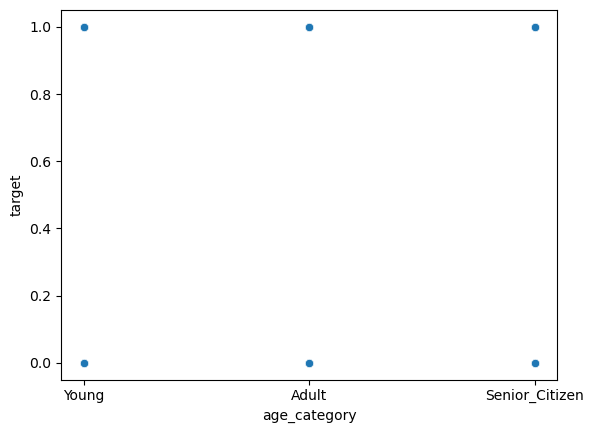

In [39]:
sns.scatterplot(data=data, x ='age_category', y = 'target' )

<Axes: xlabel='trestbps', ylabel='target'>

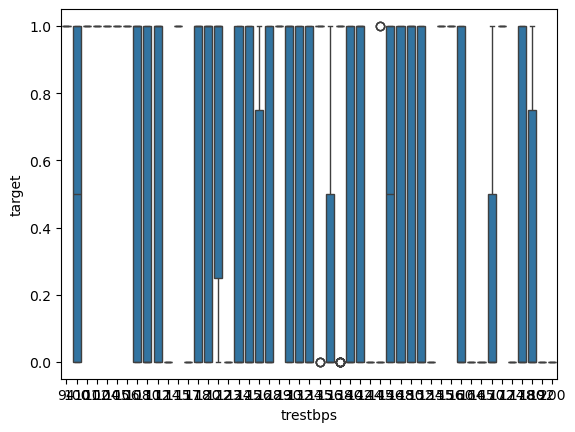

In [40]:
sns.boxplot(data=data, x = 'trestbps', y = 'target')

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import joblib

In [54]:
df = data.drop(columns = ['age_category'])

In [55]:
x = df.drop(columns = ['target'])
y = df['target']

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [57]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# Using models

In [65]:
models = {
    'logistics regression' : LogisticRegression(max_iter=1000),
    'KNN' : KNeighborsClassifier(),
    'naive bayes' : GaussianNB(),
    'Dec tree' : DecisionTreeClassifier(),
    'SVM' : SVC()
}

In [66]:
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    prediction = model.predict(x_test_scaled)
    accuracy = accuracy_score(prediction, y_test)
    print(f'{name} has accuracy : {accuracy}%')
    con_metrix = confusion_matrix(prediction, y_test)
    print(f'{con_metrix}')
    cf_report = classification_report(prediction, y_test)
    print(f'{cf_report}')


logistics regression has accuracy : 0.7804878048780488%
[[70 13]
 [32 90]]
              precision    recall  f1-score   support

           0       0.69      0.84      0.76        83
           1       0.87      0.74      0.80       122

    accuracy                           0.78       205
   macro avg       0.78      0.79      0.78       205
weighted avg       0.80      0.78      0.78       205

KNN has accuracy : 0.8439024390243902%
[[79  9]
 [23 94]]
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        88
           1       0.91      0.80      0.85       117

    accuracy                           0.84       205
   macro avg       0.84      0.85      0.84       205
weighted avg       0.85      0.84      0.84       205

naive bayes has accuracy : 0.8097560975609757%
[[73 10]
 [29 93]]
              precision    recall  f1-score   support

           0       0.72      0.88      0.79        83
           1       0.90      0.76     

In [67]:
joblib.dump(models['SVM'], 'model_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(x.columns.tolist(), 'columns.pkl')

['columns.pkl']